**Importing the dependencies**

In [45]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split , GridSearchCV , cross_val_score
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report , confusion_matrix , accuracy_score
import pickle

**Data Collection and Processing**

In [46]:
# Loding the data into pandas dataframe
rainfall_data = pd.read_csv('/content/Rainfall.csv')

In [47]:
rainfall_data.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [48]:
rainfall_data.tail()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
361,27,1022.7,18.8,17.7,16.9,15.0,84,90,yes,0.0,30.0,18.4
362,28,1026.6,18.6,17.3,16.3,12.8,75,85,yes,1.0,20.0,25.9
363,29,1025.9,18.9,17.7,16.4,13.3,75,78,yes,4.6,70.0,33.4
364,30,1025.3,19.2,17.3,15.2,13.3,78,86,yes,1.2,20.0,20.9
365,31,1026.4,20.5,17.8,15.5,13.0,74,66,no,5.7,20.0,23.3


In [49]:
rainfall_data.shape

(366, 12)

In [50]:
rainfall_data['day'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [51]:
rainfall_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temparature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    object 
 9   sunshine                366 non-null    float64
 10           winddirection  365 non-null    float64
 11  windspeed               365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


In [52]:
rainfall_data.columns

Index(['day', 'pressure ', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity ', 'cloud ', 'rainfall', 'sunshine', '         winddirection',
       'windspeed'],
      dtype='object')

In [53]:
 # remove extra spaces in all columns
rainfall_data.columns = rainfall_data.columns.str.strip()

In [54]:
rainfall_data.columns

Index(['day', 'pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity', 'cloud', 'rainfall', 'sunshine', 'winddirection',
       'windspeed'],
      dtype='object')

In [55]:
rainfall_data = rainfall_data.drop(['day'], axis=1)

In [56]:
rainfall_data.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


In [57]:
# Cheaking the no of missing values
rainfall_data.isnull().sum()

,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
rainfall,0
sunshine,0
winddirection,1


In [58]:
rainfall_data['winddirection'].unique()

array([ 80.,  50.,  40.,  20.,  30.,  60.,  70.,  10., 200., 220., 120.,
       190., 210., 300., 240., 180., 230.,  90., 170., 150., 100., 130.,
        nan, 160., 270., 280., 250., 260., 290., 350., 110., 140.])

In [59]:
# handling the missing Value
rainfall_data['winddirection'] = rainfall_data['winddirection'].fillna(rainfall_data['winddirection'].mode()[0])
rainfall_data['windspeed'] = rainfall_data['windspeed'].fillna(rainfall_data['windspeed'].mode()[0])


In [60]:
rainfall_data.isnull().sum()

,0
pressure,0
maxtemp,0
temparature,0
mintemp,0
dewpoint,0
humidity,0
cloud,0
rainfall,0
sunshine,0
winddirection,0


In [61]:
rainfall_data['rainfall'].unique()

array(['yes', 'no'], dtype=object)

In [62]:
# converting the yes and no with 1 and 0 respectively
rainfall_data['rainfall'] = rainfall_data['rainfall'].replace(['yes','no'],[1,0])

/tmp/ipykernel_3690/4197301309.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rainfall_data['rainfall'] = rainfall_data['rainfall'].replace(['yes','no'],[1,0])


In [63]:
rainfall_data.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,19.9,18.3,16.8,13.1,72,49,1,9.3,80.0,26.3
1,1022.0,21.7,18.9,17.2,15.6,81,83,1,0.6,50.0,15.3
2,1019.7,20.3,19.3,18.0,18.4,95,91,1,0.0,40.0,14.2
3,1018.9,22.3,20.6,19.1,18.8,90,88,1,1.0,50.0,16.9
4,1015.9,21.3,20.7,20.2,19.9,95,81,1,0.0,40.0,13.7


**Exploratory Data Analysis (EDA)**

In [64]:
rainfall_data.shape

(366, 11)

In [65]:
from ipywidgets import Style
# setting the plot style for all the plots
sns.set(style ="whitegrid")

In [66]:
rainfall_data.describe()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,1013.742623,26.191257,23.747268,21.894536,19.989071,80.177596,71.128415,0.680328,4.419399,101.284153,21.517760
std,6.414776,5.978343,5.632813,5.594153,5.997021,10.062470,21.798012,0.466988,3.934398,81.722827,10.062633
min,998.500000,7.100000,4.900000,3.100000,-0.400000,36.000000,0.000000,0.000000,0.000000,10.000000,4.400000
25%,1008.500000,21.200000,18.825000,17.125000,16.125000,75.000000,58.000000,0.000000,0.500000,40.000000,13.725000
50%,1013.000000,27.750000,25.450000,23.700000,21.950000,80.500000,80.000000,1.000000,3.500000,70.000000,20.500000
75%,1018.100000,31.200000,28.600000,26.575000,25.000000,87.000000,88.000000,1.000000,8.200000,190.000000,27.825000
max,1034.600000,36.300000,32.400000,30.000000,26.700000,98.000000,100.000000,1.000000,12.100000,350.000000,59.500000


In [67]:
rainfall_data.columns

Index(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity',
       'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed'],
      dtype='object')

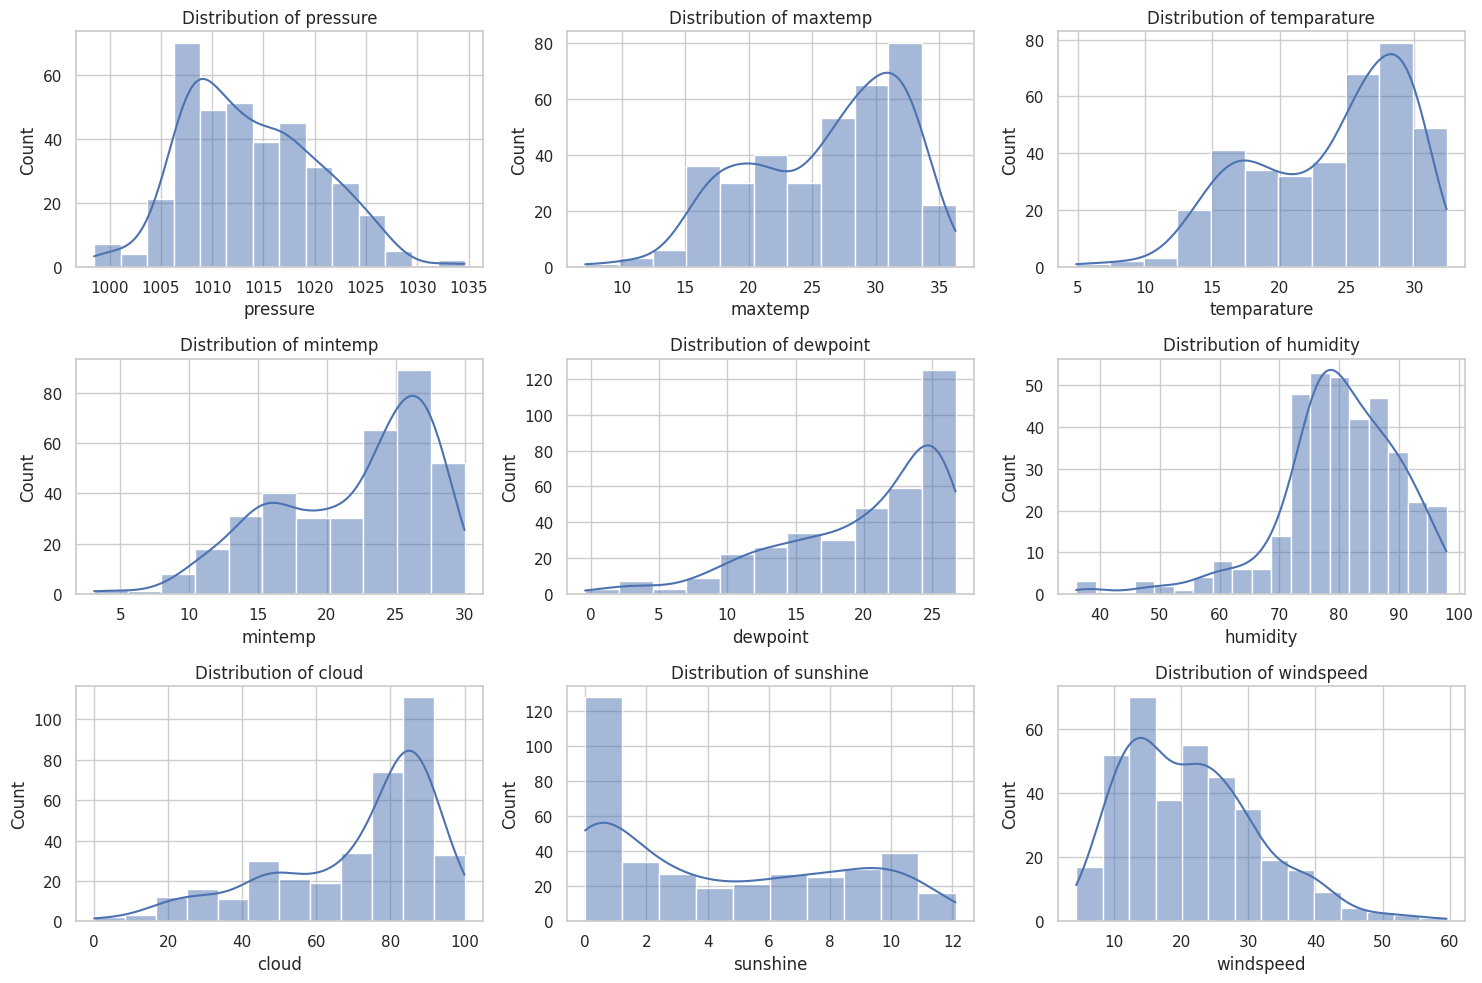

In [68]:
plt.figure(figsize=(15,10))

for i, column in enumerate(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity', 'cloud', 'sunshine', 'windspeed'], 1):
  plt.subplot(3, 3, i)
  sns.histplot(rainfall_data[column], kde=True)
  plt.title(f"Distribution of {column}")

plt.tight_layout()
plt.show()



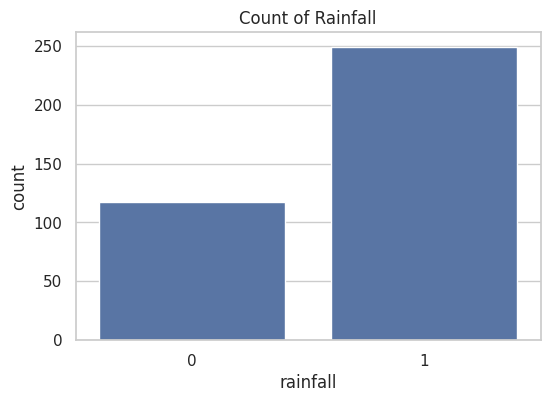

In [69]:
plt.figure(figsize=(6 , 4))
sns.countplot(x = "rainfall" , data=rainfall_data)
plt.title("Count of Rainfall")
plt.show()

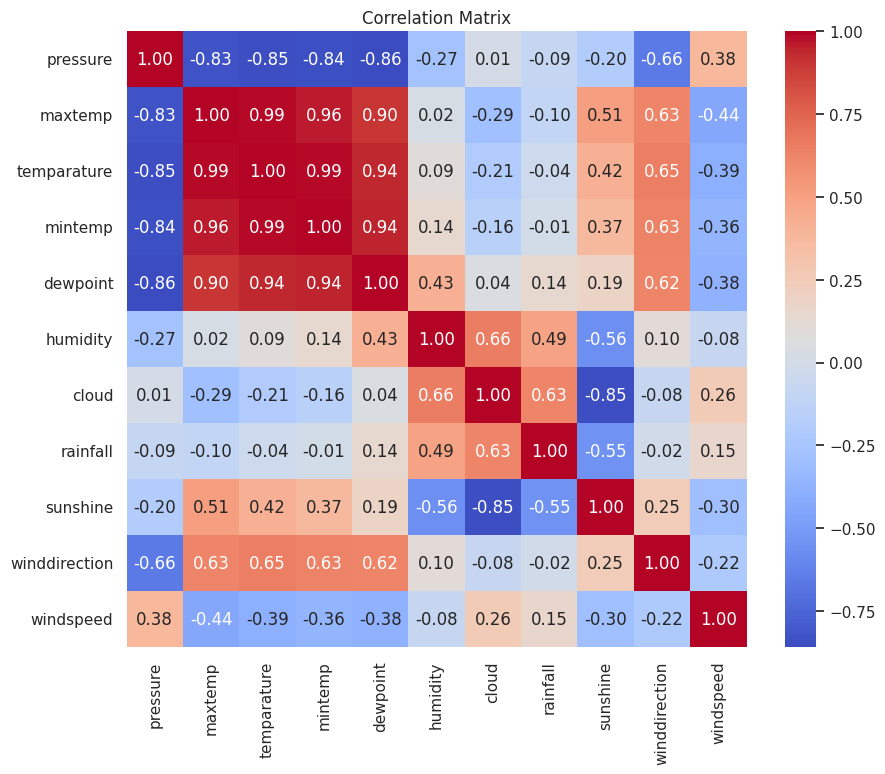

In [70]:
# correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(rainfall_data.corr(), annot=True, cmap='coolwarm' , fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

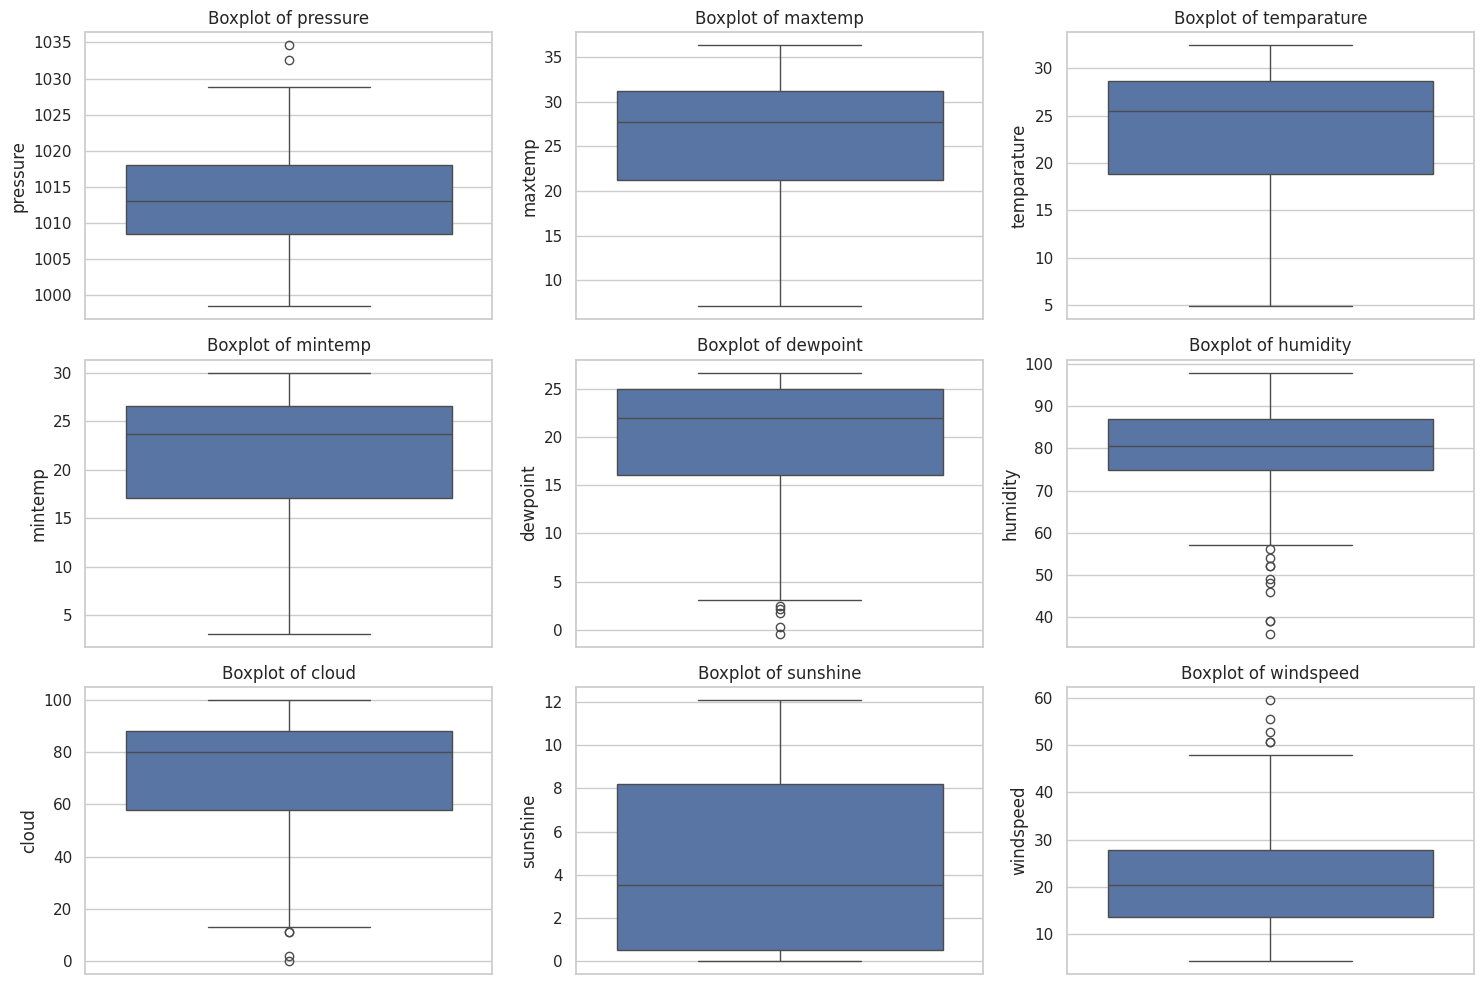

In [71]:
# box plot to check outliers in data

plt.figure(figsize=(15,10))

for i, column in enumerate(['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity', 'cloud', 'sunshine', 'windspeed'], 1):
  plt.subplot(3, 3, i)
  sns.boxplot(rainfall_data[column])
  plt.title(f"Boxplot of {column}")

plt.tight_layout()
plt.show()



**Data Pre-Processing**

In [72]:
# drop highly correlated columns
rainfall_data = rainfall_data.drop(['maxtemp', 'mintemp', 'temparature'], axis=1)

In [73]:
rainfall_data.head()

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1025.9,13.1,72,49,1,9.3,80.0,26.3
1,1022.0,15.6,81,83,1,0.6,50.0,15.3
2,1019.7,18.4,95,91,1,0.0,40.0,14.2
3,1018.9,18.8,90,88,1,1.0,50.0,16.9
4,1015.9,19.9,95,81,1,0.0,40.0,13.7


In [74]:
rainfall_data['rainfall'].value_counts()

,count
rainfall,
1,249
0,117


In [75]:
# separate majority and minority class
df_majority = rainfall_data[rainfall_data['rainfall'] == 1]
df_minority = rainfall_data[rainfall_data['rainfall'] == 0]

In [76]:
print(df_majority.shape)
print(df_minority.shape)

(249, 8)
(117, 8)


In [77]:
# downsample majority class to mach minority class

df_majority_downsample = resample(df_majority , replace=False , n_samples=len(df_minority) , random_state=42)

In [78]:
df_majority_downsample.shape

(117, 8)

In [79]:
df_downsample = pd.concat([df_majority_downsample , df_minority])

In [80]:
df_downsample.shape

(234, 8)

In [81]:
df_downsample.head()

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
188,1005.9,25.6,77,53,1,10.5,270.0,11.3
9,1017.5,15.5,85,91,1,0.0,70.0,37.7
137,1012.3,20.1,80,86,1,0.3,80.0,39.5
89,1018.3,16.3,79,89,1,2.4,40.0,14.8
157,1008.8,24.7,91,80,1,2.2,20.0,11.2


In [82]:
# shuffle the final datafreame
df_downsample = df_downsample.sample(frac=1, random_state=42).reset_index(drop=True)

In [83]:
df_downsample.head()

,pressure,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1022.2,14.1,78,90,1,0.0,30.0,28.5
1,1013.4,19.5,69,17,0,10.5,70.0,12.4
2,1006.1,24.4,74,27,0,10.8,220.0,8.7
3,1007.6,24.8,85,84,1,1.8,70.0,34.8
4,1021.2,8.4,66,18,0,10.1,20.0,24.4


In [84]:
df_downsample['rainfall'].value_counts()

,count
rainfall,
1,117
0,117


In [85]:
# split the feature and targets
X = df_downsample.drop('rainfall', axis=1)
Y = df_downsample['rainfall']

In [86]:
# splitting the data into training data and test data
X_train ,X_test , Y_train ,Y_test = train_test_split(X , Y , test_size=0.2 , random_state=42)

In [87]:
rf_model = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'max_features': ['sqrt', 'log2'],
    "min_samples_split" : [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4]
}

In [88]:
# Hypertuning using GridserchCV
grid_search_rf = GridSearchCV(estimator=rf_model, param_grid=param_grid_rf, cv=5, n_jobs=-1 ,verbose=2)

grid_search_rf.fit(X_train, Y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20, 30],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             verbose=2)

In [89]:
best_rf_model = grid_search_rf.best_estimator_
print("Best parameter for Random Forest Model:", grid_search_rf.best_params_)

Best parameter for Random Forest Model: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}


**Model Evaluation**

In [90]:
cv_score = cross_val_score(best_rf_model, X_train, Y_train, cv=5)
print("Cross-validation scores:", cv_score)
print("Mean cross-validation score:", np.mean(cv_score))

Cross-validation scores: [0.71052632 0.81578947 0.83783784 0.83783784 0.91891892]
Mean cross-validation score: 0.8241820768136557


In [100]:
# test set performan
y_pred = best_rf_model.predict(X_test)

print("Classification Report:\n", classification_report(Y_test, y_pred))
print("Test Confusion Matrix:\n", confusion_matrix(Y_test, y_pred))
print("Test Accuracy Score:", accuracy_score(Y_test, y_pred))

print("Cross-validation scores:", cv_score)
print("Mean cross-validation score:", np.mean(cv_score))

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.71      0.74        24
           1       0.72      0.78      0.75        23

    accuracy                           0.74        47
   macro avg       0.75      0.75      0.74        47
weighted avg       0.75      0.74      0.74        47

Test Confusion Matrix:
 [[17  7]
 [ 5 18]]
Test Accuracy Score: 0.7446808510638298
Cross-validation scores: [0.71052632 0.81578947 0.83783784 0.83783784 0.91891892]
Mean cross-validation score: 0.8241820768136557


Prediction on unknown data

In [92]:
input_data = (1015.9, 19.9, 95, 81, 0.0, 40.0, 13.7)

input_df = pd.DataFrame([input_data], columns=['pressure', 'dewpoint', 'humidity', 'cloud', 'sunshine', 'winddirection', 'windspeed'])

prediction = best_rf_model.predict(input_df)

print("Prediction result : " , "Rainfall" if prediction[0] == 1 else "No Rainfall")

Prediction result :  Rainfall


In [94]:
# save model and feature names to a pickel file
model_data = {'model': best_rf_model, 'feature_names': X.columns.tolist()}

with open('rainfall_prediction_model.pkl', 'wb') as file:
    pickle.dump(model_data, file)

**Load the saved model file and file and use it for prediction**

In [95]:
import pickle
import pandas as pd

In [98]:
# load the trained model and feature names for the pickel file
with open('rainfall_prediction_model.pkl', 'rb') as file:
    model_data = pickle.load(file)

model = model_data['model']
feature_names = model_data['feature_names']

In [99]:
input_data = (1015.9, 19.9, 95, 81, 0.0, 40.0, 13.7)

input_df = pd.DataFrame([input_data], columns=feature_names)

prediction = model.predict(input_df)

print("Prediction result : " , "Rainfall" if prediction[0] == 1 else "No Rainfall")


Prediction result :  Rainfall


**Thing we can try to incress performance**

**To try**
1. SMOTE for class Balancing
2. PCA for dimensionnality reductuion
3. simpler model like logistic Regression (with feature scaling)
4. model selection with Hyperparameter tuning